<div style="font-family: Arial, sans-serif; background-color: #f8f9fa; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">
  <div style="display: flex; justify-content: space-between; align-items: center;">
    <img src="https://sigmoidal.ai/wp-content/uploads/2024/09/Academia-Sigmoidal-Light.png" alt="Academia Sigmoidal Logo" width="250" height="auto">
    <div style="text-align: right;">
<h1 style="color: #007bff; margin: 0; font-size: 24px;">Bootcamp de Visão Computacional Aplicada a Drones</h1>
    </div>
</div>
<hr style="border: none; height: 1px; background-color: #007bff; margin: 20px 0;">
<h3 style="color: #343a40; margin: 0; font-size: 20px;"><strong>Projeto 2 · Preparando imagens e anotações</strong></h3>
<p style="color: #6c757d; margin: 5px 0 0; font-size: 14px;"><strong>Instrutor:</strong> Carlos Melo, MSc.</p>
</div>

# Do par de imagens à entrada do detector

Este notebook prepara **uma amostra do RGBTDronePerson**: um par RGB e térmico, suas caixas e as classes dessas caixas.
O percurso inclui abrir o par, interpretar as coordenadas, espelhar imagens e caixas juntas e preparar os valores e as dimensões dos arrays.

Use o kernel **Projeto 2 - EDA**, preparado conforme o [README](README.md). Os dados são os mesmos do Notebook 00:
na pasta `projeto-2`, execute `.venv-eda/bin/python suporte/preparar_dados.py --rgbtdroneperson` caso ainda não estejam disponíveis.
A atividade usa NumPy, Pillow e Matplotlib em CPU e não instala pacotes nas células.

## Localizar os dados

`Path` representa um caminho no computador. O código abaixo encontra `dados/` quando o notebook é aberto na pasta do Projeto 2 ou na raiz do repositório. Os arquivos originais serão apenas lidos; as transformações ficam na memória.

In [1]:
from pathlib import Path

DADOS = Path("dados")
if not (DADOS / "anotacoes-oficiais-extras").is_dir():
    DADOS = Path("projeto-2/dados")

O módulo `json` lê as anotações. Pillow abre as imagens, NumPy permite trabalhar com seus pixels e Matplotlib mostra os resultados. `Rectangle` será usado para desenhar uma caixa.

In [2]:
%matplotlib inline
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.patches import Rectangle

plt.rcParams.update({"font.family": "sans-serif", "font.size": 12})

## Abrir um par

A amostra escolhida é a cena diurna `01000.jpg`. No JSON, `images` é a lista de imagens; cada registro contém um identificador e o nome do arquivo. `next(...)` busca o primeiro registro cujo nome coincide com o escolhido.

O mesmo nome identifica as imagens nas pastas `visible` e `thermal`. `np.array(...)` transforma cada imagem em uma tabela de pixels com três eixos: **altura, largura e canais**. A imagem térmica também é armazenada com três canais; isso não transforma a informação térmica em cores visíveis nem em temperatura medida.

In [3]:
with open(DADOS / "anotacoes-oficiais-extras/train_thermal.json") as arquivo:
    treino = json.load(arquivo)
exemplo = next(item for item in treino["images"] if item["file_name"] == "01000.jpg")
rgb = np.array(Image.open(DADOS / "train/visible" / exemplo["file_name"]).convert("RGB"))
termica = np.array(Image.open(DADOS / "train/thermal" / exemplo["file_name"]).convert("RGB"))
altura, largura = rgb.shape[:2]
print("Arquivo:", exemplo["file_name"])
print("RGB:", rgb.shape, rgb.dtype)
print("Térmico:", termica.shape, termica.dtype)

Arquivo: 01000.jpg
RGB: (512, 640, 3) uint8
Térmico: (512, 640, 3) uint8


A saída `(512, 640, 3)` significa 512 linhas, 640 colunas e 3 canais. `uint8` armazena valores inteiros de 0 a 255. Em `shape[:2]`, a expressão seleciona apenas os dois primeiros eixos para obter altura e largura.

O pipeline oficial usa **redimensionamento** para 640 × 512, preservando a proporção, e **padding**, que acrescenta bordas até as dimensões serem múltiplas de 32. O par já tem 640 × 512, e ambas as dimensões são múltiplas de 32: essas etapas não alterariam seu tamanho. Por isso, as imagens mantêm o tamanho original.

## Selecionar caixas e classes

`annotations` contém as anotações de todas as imagens. A seleção mantém somente as que têm o `image_id` da cena escolhida e pertencem a uma das três classes usadas pelo detector. Os IDs abaixo são os IDs presentes neste JSON; `uncertain`, de ID 3, fica fora da seleção.

No laço, `in classes` verifica se o ID é uma chave do dicionário, e `append` adiciona a anotação à lista. A expressão `[a["category_id"] for a in anotacoes]` percorre essa lista e reúne os IDs das classes na mesma ordem.

In [4]:
classes = {0: "person", 1: "rider", 2: "crowd"}
anotacoes = []
for anotacao in treino["annotations"]:
    mesma_imagem = anotacao["image_id"] == exemplo["id"]
    classe_alvo = anotacao["category_id"] in classes
    if mesma_imagem and classe_alvo:
        anotacoes.append(anotacao)
rotulos = np.array([a["category_id"] for a in anotacoes])
print("Classes:", classes)
print("Caixas selecionadas:", len(anotacoes))

Classes: {0: 'person', 1: 'rider', 2: 'crowd'}
Caixas selecionadas: 23


## Da largura e altura aos dois cantos

Cada `bbox` no JSON contém `[x, y, w, h]`: posição do canto superior esquerdo, largura e altura. **Na convenção destes arquivos**, a origem fica no canto superior esquerdo; `x` cresce para a direita e `y` cresce para baixo.

A mesma caixa pode ser representada por `[x1, y1, x2, y2]`, os cantos superior esquerdo e inferior direito. Basta manter o primeiro canto e somar largura e altura:

$$x_2 = x_1 + w \qquad y_2 = y_1 + h$$

O array terá uma linha por caixa e quatro colunas. Em `[:, 2]`, `:` seleciona todas as linhas e `2` seleciona a terceira coluna, pois os índices começam em zero. `.copy()` preserva a versão original. Usamos `float32`, que permite coordenadas fracionárias em futuras transformações.

A nona anotação, de índice 8, permite acompanhar uma pessoa de perto. É a caixa de 9 × 19 pixels que apareceu no Notebook 00.

In [5]:
caixas_xywh = np.array([a["bbox"] for a in anotacoes], dtype=np.float32)
caixas = caixas_xywh.copy()
caixas[:, 2] = caixas_xywh[:, 0] + caixas_xywh[:, 2]
caixas[:, 3] = caixas_xywh[:, 1] + caixas_xywh[:, 3]
indice = 8
print("xywh:", caixas_xywh[indice])
print("xyxy:", caixas[indice])

xywh: [398. 289.   9.  19.]
xyxy: [398. 289. 407. 308.]


A posição inicial é `(398, 289)`; somando 9 à posição horizontal e 19 à vertical, o outro canto fica em `(407, 308)`. A representação muda, mantendo a mesma região da imagem.

A figura abaixo amplia essa região térmica. `Rectangle` recebe posição, largura e altura, por isso usamos `x2 - x1` e `y2 - y1` para desenhar. `xlim` e `ylim` aproximam a visualização sem recortar ou modificar o array; os pontos marcam os dois cantos.

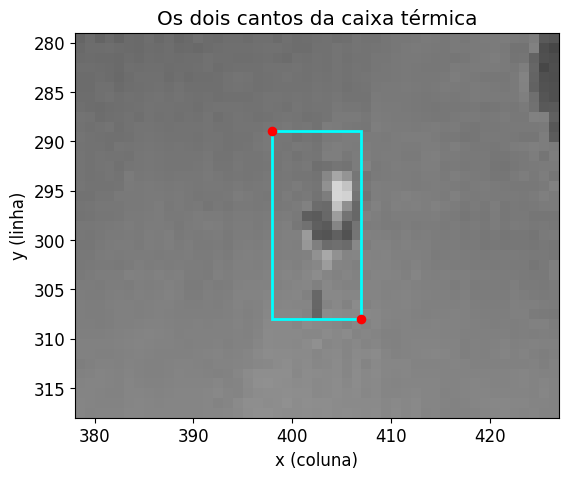

In [6]:
x1, y1, x2, y2 = caixas[indice]
plt.figure(figsize=(7, 5))
plt.imshow(termica, extent=(0, largura, altura, 0), interpolation="nearest")
plt.gca().add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color="cyan", lw=2))
plt.scatter([x1, x2], [y1, y2], color="red", s=35)
plt.xlim(x1 - 20, x2 + 20)
plt.ylim(y2 + 10, y1 - 10)
plt.xlabel("x (coluna)")
plt.ylabel("y (linha)")
plt.title("Os dois cantos da caixa térmica")
plt.show()

## Espelhar o par e as caixas

**Aumento de dados** apresenta versões transformadas dos exemplos durante o treino. O código oficial espelha horizontalmente com probabilidade de 50%. O exemplo aplica o espelhamento uma vez para mostrar seu efeito; na inferência oficial ele fica desativado.

Em `imagem[:, ::-1]`, a expressão mantém todas as linhas e percorre as colunas de trás para a frente. A mesma operação precisa ser aplicada aos dois sensores. As classes continuam iguais, mas as caixas precisam acompanhar a nova posição dos objetos.

Se a largura da imagem é $W$, o antigo limite direito determina o novo limite esquerdo:

$$x'_1 = W - x_2 \qquad x'_2 = W - x_1$$

Os limites verticais não mudam. A fórmula usa **bordas de caixas**, entre 0 e $W$; isso é diferente dos índices dos pixels, entre 0 e $W-1$. Para a caixa destacada, os limites horizontais passam de `[398, 407]` para `[233, 242]`.

O código transforma todas as caixas. A lista `paineis` apenas reúne imagem, caixas e título para a comparação seguinte.

In [7]:
rgb_espelhado = rgb[:, ::-1].copy()
termica_espelhada = termica[:, ::-1].copy()
caixas_espelhadas = caixas.copy()
caixas_espelhadas[:, 0] = largura - caixas[:, 2]
caixas_espelhadas[:, 2] = largura - caixas[:, 0]
print("Caixa espelhada:", caixas_espelhadas[indice])
paineis = [(rgb, caixas, "RGB original"), (termica, caixas, "Térmico original"),
           (rgb_espelhado, caixas_espelhadas, "RGB espelhado"),
           (termica_espelhada, caixas_espelhadas, "Térmico espelhado")]

Caixa espelhada: [233. 289. 242. 308.]


A primeira linha mostra o par original, e a segunda mostra o par espelhado. Para enxergar a pessoa, cada painel aproxima a região da caixa destacada; as imagens completas continuam na memória.

`axes.flat` percorre os quatro painéis, e `zip` associa cada um à imagem, às caixas e ao título correspondentes. A caixa desenhada nos dois sensores usa sempre a anotação térmica.

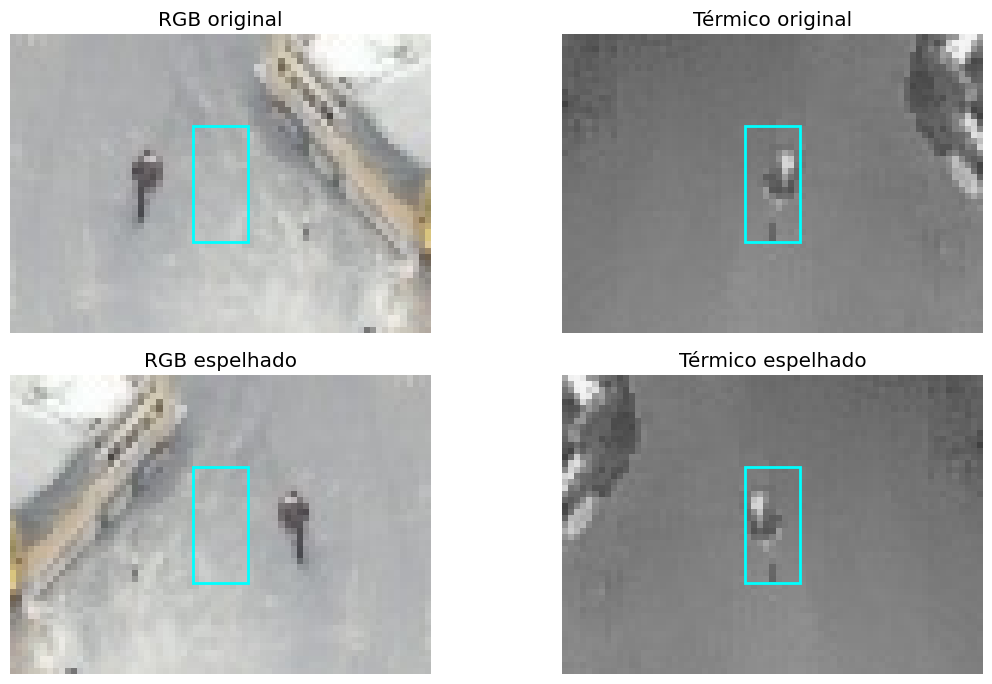

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (imagem, caixas_atuais, titulo) in zip(axes.flat, paineis):
    x1, y1, x2, y2 = caixas_atuais[indice]
    ax.imshow(imagem, extent=(0, largura, altura, 0), interpolation="nearest")
    ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color="cyan", lw=2))
    ax.set_xlim(x1 - 30, x2 + 30)
    ax.set_ylim(y2 + 15, y1 - 15)
    ax.set_title(titulo)
    ax.axis("off")
plt.tight_layout()
plt.show()

A caixa acompanha a pessoa no térmico. No RGB, o deslocamento que já existia também foi espelhado: transformar o par junto preserva sua relação, mas não corrige o desalinhamento dos sensores.

## Normalizar os valores de cada sensor

As etapas seguintes usam o **par original**, como na preparação para inferência. As imagens espelhadas ficam como demonstração de aumento de dados no treino.

A normalização coloca os valores na escala esperada pelo modelo. Para cada valor de pixel $p$, subtraímos a média $\mu$ e dividimos pelo desvio padrão $\sigma$:

$$z = \frac{p - \mu}{\sigma}$$

A normalização usa as constantes da configuração oficial. No RGB, há um valor para cada canal; no térmico, os três canais usam a mesma média e o mesmo desvio. O NumPy aplica os três valores RGB a todos os pixels, respeitando a ordem dos canais, sem um laço explícito por pixel.

`.astype(np.float32)` permite resultados fracionários e negativos. Essas constantes usam intensidades na escala **0–255**, portanto a imagem não deve ser dividida por 255 antes. Pillow já abriu as imagens em RGB; não é necessário inverter a ordem dos canais.

O cálculo será conferido em um pixel térmico dentro da pessoa: linha 298, coluna 402, canal 0. No array, o acesso é `[linha, coluna, canal]`, ou seja, `[y, x, canal]`.

In [9]:
media_rgb = np.array([115.37, 121.82, 122.63], dtype=np.float32)
desvio_rgb = np.array([85.13, 89.01, 88.27], dtype=np.float32)
rgb_normalizado = (rgb.astype(np.float32) - media_rgb) / desvio_rgb
termica_normalizada = (termica.astype(np.float32) - 93.10) / 50.24
pixel = termica[298, 402, 0]
print("Intensidade térmica:", pixel)
print("Cálculo normalizado:", round((float(pixel) - 93.10) / 50.24, 3))
print("Valor no array:", round(float(termica_normalizada[298, 402, 0]), 3))

Intensidade térmica: 95
Cálculo normalizado: 0.038
Valor no array: 0.038


O valor calculado coincide com o valor no array. Essa normalização pode produzir números negativos ou maiores que 1; ela muda a escala dos valores, mantendo as posições dos pixels e das caixas.

As constantes são fixas, compartilhadas pelo treino e pela inferência. Não se calcula uma nova média para cada imagem. As visualizações usam os arrays originais, pois `imshow` não deve interpretar esses valores normalizados como intensidades comuns.

## Colocar os canais primeiro

Até aqui, a ordem dos eixos é **HWC**: altura (*height*), largura (*width*) e canais (*channels*). O detector trabalha com **CHW**, colocando os canais primeiro.

Em `transpose(2, 0, 1)`, o antigo eixo 2 vira o primeiro, seguido dos antigos eixos 0 e 1. Os pixels mantêm seus valores e sua posição na cena; apenas os eixos do array são reorganizados. `.copy()` guarda o resultado nessa nova organização.

Cada sensor continua separado. A saída apresenta forma e tipo das duas entradas, das caixas e dos rótulos. A linha de índice `i` em `caixas` continua correspondendo ao elemento de índice `i` em `rotulos`.

In [10]:
entrada_rgb = rgb_normalizado.transpose(2, 0, 1).copy()
entrada_termica = termica_normalizada.transpose(2, 0, 1).copy()
print("RGB:", entrada_rgb.shape, entrada_rgb.dtype)
print("Térmico:", entrada_termica.shape, entrada_termica.dtype)
print("Caixas:", caixas.shape, caixas.dtype)
print("Rótulos:", rotulos.shape, rotulos.dtype)

RGB: (3, 512, 640) float32
Térmico: (3, 512, 640) float32
Caixas: (23, 4) float32
Rótulos: (23,) int64


## O que temos ao final

O resultado contém duas entradas `(3, 512, 640)` em `float32`, acompanhadas das 23 caixas térmicas em `xyxy` e dos 23 rótulos. Os dados originais e a divisão entre treino e validação foram preservados.

O espelhamento mostrou por que imagens e caixas precisam ser transformadas juntas. A normalização e a reorganização dos eixos mostraram como os pixels são apresentados à rede. Esta etapa usa arrays NumPy de uma amostra; a conversão para tensores e a organização em lote entram na integração com o detector.

O Notebook 02 executa um modelo com pesos já treinados e compara suas previsões com as anotações.

## Referências

- Zhang et al. (2023), [Drone-based RGBT tiny person detection](https://doi.org/10.1016/j.isprsjprs.2023.08.016), seções 3.1 e 5.1.
- [Configuração oficial do QFDet](https://github.com/NNNNerd/mmdet-rgbtdroneperson/blob/a79210c283597294ded255028bb8fe16e1c241cd/qfdet_configs/qfdet_r50_fpn_1x_rgbtdroneperson.py#L99-L147): escala, espelhamento, normalização e padding.
- [Transformações oficiais](https://github.com/NNNNerd/mmdet-rgbtdroneperson/blob/a79210c283597294ded255028bb8fe16e1c241cd/mmdet/datasets/pipelines/transforms.py#L370-L474) e [normalização por modalidade](https://github.com/NNNNerd/mmdet-rgbtdroneperson/blob/a79210c283597294ded255028bb8fe16e1c241cd/mmdet/datasets/pipelines/multispectral_transforms.py#L13-L43).